In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stock-market-prediction/stocks.csv


## Library 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.pipeline import Pipeline

## **1.Dataset Loading**

In [3]:
df=pd.read_csv('/kaggle/input/stock-market-prediction/stocks.csv')

In [4]:
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [5]:
df['Date']=pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Ticker     248 non-null    object        
 1   Date       248 non-null    datetime64[ns]
 2   Open       248 non-null    float64       
 3   High       248 non-null    float64       
 4   Low        248 non-null    float64       
 5   Close      248 non-null    float64       
 6   Adj Close  248 non-null    float64       
 7   Volume     248 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 15.6+ KB


## **2.EDA (Regression Problem)**

In [7]:
df['Week Day']=df['Date'].dt.weekday
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month

In [8]:
df=df.drop(columns=['Date'])

In [9]:
X=df.drop(columns=['Volume'])

In [10]:
df['Ticker'].value_counts()

Ticker
AAPL    62
MSFT    62
NFLX    62
GOOG    62
Name: count, dtype: int64

<Axes: xlabel='Ticker', ylabel='count'>

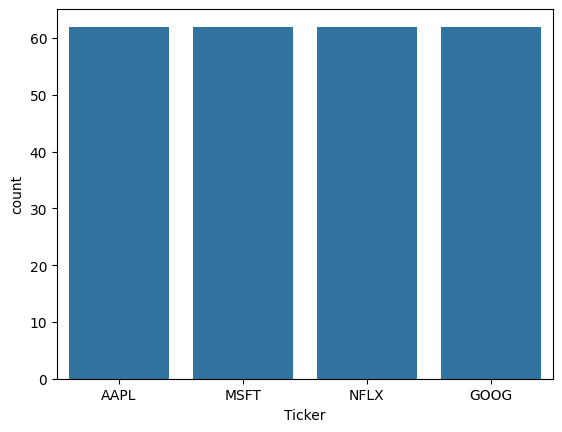

In [11]:
sns.countplot(x=df['Ticker'],data=X)

In [12]:
X.head()

,Ticker,Open,High,Low,Close,Adj Close,Week Day,Year,Month
0,AAPL,150.639999,155.229996,150.639999,154.649994,154.414230,1,2023,2
1,AAPL,153.880005,154.580002,151.169998,151.919998,151.688400,2,2023,2
2,AAPL,153.779999,154.330002,150.419998,150.869995,150.639999,3,2023,2
3,AAPL,149.460007,151.339996,149.220001,151.009995,151.009995,4,2023,2
4,AAPL,150.949997,154.259995,150.919998,153.850006,153.850006,0,2023,2


In [13]:
y=df['Volume']
y.head()

0    83322600
1    64120100
2    56007100
3    57450700
4    62199000
Name: Volume, dtype: int64

In [14]:
categorical_columns=X.select_dtypes(include=['object']).columns
numerical_columns=X.select_dtypes(include=['float64','int64','int32']).columns

In [15]:
categorical_columns

Index(['Ticker'], dtype='object')

In [16]:
numerical_columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Week Day', 'Year',
       'Month'],
      dtype='object')

## Preprocessing using Column Transformer

In [17]:
preprocessor=ColumnTransformer(
    transformers=[
        ('One Hot Encoding',OneHotEncoder(),categorical_columns),
        ('Standard Scalers',StandardScaler(),numerical_columns)
    ]
)

In [18]:
preprocessor

ColumnTransformer(transformers=[('One Hot Encoding', OneHotEncoder(),
                                 Index(['Ticker'], dtype='object')),
                                ('Standard Scalers', StandardScaler(),
                                 Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Week Day', 'Year',
       'Month'],
      dtype='object'))])

## **3.Dataset Splitting**

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=43)

In [20]:
X_train.shape

(173, 9)

pip install xgboost

In [21]:
from sklearn.linear_model import LinearRegression,ElasticNet,Lasso,Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [22]:
models={
    
    'Linear Regression':LinearRegression(n_jobs=-1),
    'Elastic Net':ElasticNet(alpha=0.01,l1_ratio=0.05,max_iter=2500,random_state=43),
    'Ridge':Ridge(alpha=1,max_iter=2500,random_state=43),
    'Lasso':Lasso(alpha=0.01,max_iter=2500,random_state=43),
    'Support Vector Machines':SVR(kernel='poly',max_iter=200,C=100),
    'Knn':KNeighborsRegressor(n_neighbors=13,metric='minkowski'),
    'Decision Tree Regressor':DecisionTreeRegressor(criterion='squared_error',
                                                     splitter='random',max_depth=5,
                                                     min_samples_split=8,
                                                     min_samples_leaf=6,
                                                     random_state=43),
    'Gradient Boosting':GradientBoostingRegressor(loss='squared_error',n_estimators=200,random_state=43),
    'Random Forest':RandomForestRegressor(n_estimators=200,random_state=43,
                                          min_samples_split=8,min_samples_leaf=6
                                         ,n_jobs=-1),
    'XGB Regressor':XGBRegressor(n_estimators=200,
                                
                                learning_rate=0.05,
                                max_depth=5,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                objective='reg:squarederror',
                                random_state=42,
                                n_jobs=-1)
    
}

In [23]:
models.items()

dict_items([('Linear Regression', LinearRegression(n_jobs=-1)), ('Elastic Net', ElasticNet(alpha=0.01, l1_ratio=0.05, max_iter=2500, random_state=43)), ('Ridge', Ridge(alpha=1, max_iter=2500, random_state=43)), ('Lasso', Lasso(alpha=0.01, max_iter=2500, random_state=43)), ('Support Vector Machines', SVR(C=100, kernel='poly', max_iter=200)), ('Knn', KNeighborsRegressor(n_neighbors=13)), ('Decision Tree Regressor', DecisionTreeRegressor(max_depth=5, min_samples_leaf=6, min_samples_split=8,
                      random_state=43, splitter='random')), ('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, random_state=43)), ('Random Forest', RandomForestRegressor(min_samples_leaf=6, min_samples_split=8, n_estimators=200,
                      n_jobs=-1, random_state=43)), ('XGB Regressor', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=Non

In [24]:
results=[]

for model_name,model in models.items():
    print(f"Model name is:{model_name}")

    pipeline=Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('model',model)
    ])
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    r2=r2_score(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    results.append(
        {
            'Model name':model_name,
            'R2 Score':r2,
            'Mean squared error':mse
        }
    )
    
    
    

Model name is:Linear Regression
Model name is:Elastic Net
Model name is:Ridge
Model name is:Lasso
Model name is:Support Vector Machines
Model name is:Knn
Model name is:Decision Tree Regressor
Model name is:Gradient Boosting


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.064e+16, tolerance: 9.308e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.075e+16, tolerance: 9.308e+12
  model = cd_fast.enet_coordinate_descent(


Model name is:Random Forest
Model name is:XGB Regressor


In [25]:
results_df=pd.DataFrame(results).sort_values(by='R2 Score',ascending=False)

## **4. Model Results**

In [26]:
results_df

,Model name,R2 Score,Mean squared error
3,Lasso,0.811783,7.430372e+13
0,Linear Regression,0.809915,7.504112e+13
8,Random Forest,0.797478,7.995096e+13
9,XGB Regressor,0.791428,8.233933e+13
5,Knn,0.786177,8.441234e+13
7,Gradient Boosting,0.770823,9.047398e+13
2,Ridge,0.765073,9.274377e+13
1,Elastic Net,0.760644,9.449228e+13
6,Decision Tree Regressor,0.739807,1.027181e+14
4,Support Vector Machines,-0.005583,3.969810e+14


## **5. HyperParameter Tuning**

In [27]:
param_grids={
    
    'Linear Regression':(
        LinearRegression(n_jobs=-1),
        {}
    ),
    'Lasso':(
        Lasso(max_iter=2500,random_state=43),
        {
            'model__alpha':[0.001,0.01,0.1,1],
            'model__max_iter':[200,500,1000,1200,2500]
        }
    ),
    'Ridge':(
        Ridge(max_iter=2500,random_state=43),
        {
           'model__alpha':[0.001,0.01,0.1,1,10],
           'model__max_iter':[200,500,1000,1200,2500] 
        }
    ),
    'Elastic Net':(
        ElasticNet(max_iter=2500,random_state=43),
        {
            'model__alpha':[0.001,0.01,0.1,1,10],
            'model__max_iter':[200,500,1000,1200,2500],
            'model__l1_ratio':[0.005,0.05,0.5,0.001,0.01,0.1]
        }
    ),
    'Decision Tree Regressor': (
        DecisionTreeRegressor(random_state=43),
        
        {
            'model__max_depth': randint(3,10),
         
            'model__min_samples_split': randint(5,20),
         
            'model__min_samples_leaf': randint(3,15)
        }
    ),

    'Random Forest':(
        
        RandomForestRegressor(random_state=43),
        {
            'model__n_estimators': randint(100, 300),
            'model__max_depth': randint(5, 15),
            'model__min_samples_split': randint(5, 20),
            'model__min_samples_leaf': randint(3, 15)
        }
    ),

    'Gradient Boosting':(     
        GradientBoostingRegressor(random_state=43),
        {
            'model__n_estimators': randint(100, 300),
            'model__learning_rate': uniform(0.01, 0.2),
            'model__max_depth': randint(3, 7)
        }
    ),
    'XGB Regressor':(
        
        XGBRegressor(random_state=43),
        {
            'model__n_estimators': randint(100, 300),
            'model__learning_rate': uniform(0.01, 0.2),
            'model__max_depth': randint(3, 7),
            'model__subsample': uniform(0.7, 0.3),
            'model__colsample_bytree': uniform(0.7, 0.3)
        }
    )



    
}

In [28]:
tuned_results=[]
for model_labels,(model_obj,params)in param_grids.items():
    print(f"Model name is :{model_labels}")
    
    pipeline=Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('model',model_obj)
    ]
                     )
        
    random_grid=RandomizedSearchCV(
        pipeline,
        params,
        n_jobs=-1,
        cv=5,
        scoring='r2'
    )
    
    random_grid.fit(X_train,y_train)
    best_model=random_grid.best_estimator_
    y_pred=best_model.predict(X_test)

    tuned_results.append({'Model name':model_labels,
                          'Best R2 score':random_grid.best_score_,
                          'R2 Score':r2_score(y_test,y_pred),
                          'Test MSE':mean_squared_error(y_test,y_pred),
                          'Best Parameters':random_grid.best_params_
    })
    

Model name is :Linear Regression


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model name is :Lasso


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.616e+15, tolerance: 7.547e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.534e+15, tolerance: 7.145e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.670e+15, tolerance: 7.509e

Model name is :Ridge
Model name is :Elastic Net


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.374e+15, tolerance: 7.547e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.038e+16, tolerance: 7.145e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.033e+16, tolerance: 7.509e

Model name is :Decision Tree Regressor
Model name is :Random Forest
Model name is :Gradient Boosting
Model name is :XGB Regressor


## **6. Tuned Hyper Parameter results**

In [29]:
tuned_results_df=pd.DataFrame(tuned_results).sort_values(by='R2 Score',ascending=False)

In [30]:
pd.set_option('display.max_colwidth', 0)
tuned_results_df

,Model name,Best R2 score,R2 Score,Test MSE,Best Parameters
1,Lasso,0.707605,0.811783,7.430372e+13,"{'model__max_iter': 2500, 'model__alpha': 0.01}"
2,Ridge,0.711954,0.811166,7.454712e+13,"{'model__max_iter': 200, 'model__alpha': 0.01}"
0,Linear Regression,0.704709,0.809915,7.504112e+13,{}
5,Random Forest,0.713247,0.803971,7.738772e+13,"{'model__max_depth': 9, 'model__min_samples_leaf': 3, 'model__min_samples_split': 6, 'model__n_estimators': 115}"
3,Elastic Net,0.694446,0.783879,8.531967e+13,"{'model__max_iter': 1000, 'model__l1_ratio': 0.01, 'model__alpha': 0.001}"
7,XGB Regressor,0.688420,0.779382,8.709491e+13,"{'model__colsample_bytree': 0.9155363996512361, 'model__learning_rate': 0.047782353614069614, 'model__max_depth': 3, 'model__n_estimators': 109, 'model__subsample': 0.7941786138821645}"
6,Gradient Boosting,0.651959,0.770381,9.064821e+13,"{'model__learning_rate': 0.026290247326411692, 'model__max_depth': 5, 'model__n_estimators': 183}"
4,Decision Tree Regressor,0.654390,0.766962,9.199801e+13,"{'model__max_depth': 6, 'model__min_samples_leaf': 13, 'model__min_samples_split': 12}"
